## import necessary pacakged

In [98]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import utils.util as util

pd.set_option('display.max_columns', None)

## import dataset

In [99]:
df = pd.read_csv('../data/raw/dataset.csv')

## analyze the data

In [100]:
df.shape

(15000, 36)

In [101]:
df.head()

,student_id,age,gender,first_generation_college,international_student,residency_status,high_school_gpa,sat_score,act_score,advanced_courses_taken,extracurricular_activities,major,enrollment_status,semester_credits,admission_type,starting_semester,family_income,financial_aid_received,pell_grant_eligible (scholarship),student_loan_amount,has_campus_job,current_gpa,credits_completed,courses_failed,courses_withdrawn,attendance_rate,study_hours_per_week,library_visits_per_month,tutoring_sessions_attended,advisor_meetings,clubs_joined,living_arrangement,has_disability,distance_from_campus_miles,work_hours_per_week,dropped_out
0,STU_00000001,23,Male,No,No,In-state,2.88,1034.0,26,2,2,Health Sciences,Full-time,12,Transfer,Fall,$30k-$60k,Yes,No,239,Yes,3.63,23,0,0,73.6,21,0,0,3,0,On-campus,No,64,18,No
1,STU_00000002,20,Male,Yes,No,In-state,2.79,1162.0,20,3,2,Social Sciences,Full-time,18,Regular,Spring,$60k-$100k,No,Yes,24364,No,1.92,45,2,3,77.6,11,4,2,1,2,On-campus,No,0,2,Yes
2,STU_00000003,19,Female,No,No,In-state,3.44,1264.0,22,5,2,Arts & Sciences,Full-time,12,Regular,Fall,$60k-$100k,Yes,No,18313,Yes,2.13,96,0,0,69.9,28,2,2,1,0,On-campus,No,10,5,Yes
3,STU_00000004,17,Male,No,Yes,In-state,2.86,966.0,28,4,3,Engineering,Full-time,18,Regular,Fall,$30k-$60k,Yes,No,11918,Yes,3.22,3,0,1,83.8,24,1,0,0,1,Off-campus,No,24,27,No
4,STU_00000005,17,Male,Yes,Yes,Out-of-state,3.77,1174.0,25,8,1,Business,Full-time,15,Early Decision,Fall,$30k-$60k,Yes,No,6449,No,3.18,1,1,1,NaN,7,7,5,1,0,On-campus,No,15,10,No


In [102]:
df.isnull().sum()[df.isnull().sum() > 0]

sat_score          750
current_gpa        750
attendance_rate    750
dtype: int64

In [103]:
cols_with_missing_values = ['sat_score', 'current_gpa', 'attendance_rate']
df[cols_with_missing_values].dtypes

sat_score          float64
current_gpa        float64
attendance_rate    float64
dtype: object

In [104]:
# check if the columns with missing values are correlated
df[cols_with_missing_values].corr()

,sat_score,current_gpa,attendance_rate
sat_score,1.000000,0.000207,-0.000716
current_gpa,0.000207,1.000000,0.006642
attendance_rate,-0.000716,0.006642,1.000000


### all the columns are independent and can be filled independently
### check the distribution of data to find method we can use for filling missing values

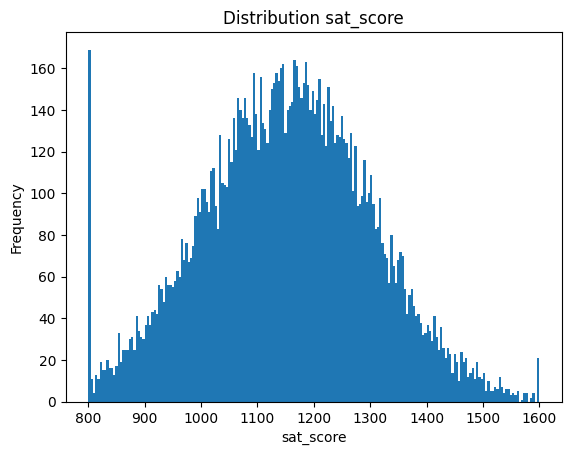

In [105]:
plt.hist(df['sat_score'], bins=200)
plt.title('Distribution sat_score')
plt.xlabel('sat_score')
plt.ylabel('Frequency')
plt.show()

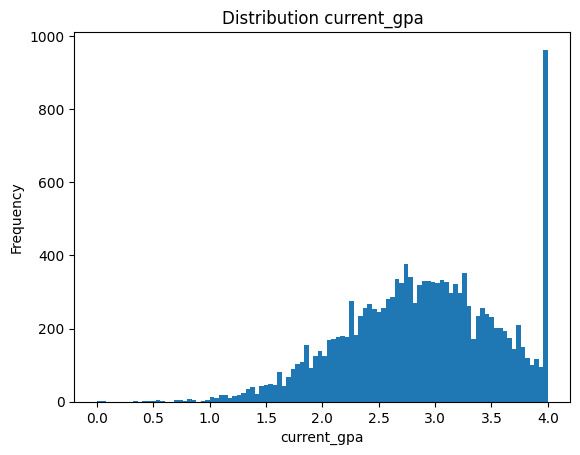

In [106]:
plt.hist(df['current_gpa'], bins=100)
plt.title('Distribution current_gpa')
plt.xlabel('current_gpa')
plt.ylabel('Frequency')
plt.show()

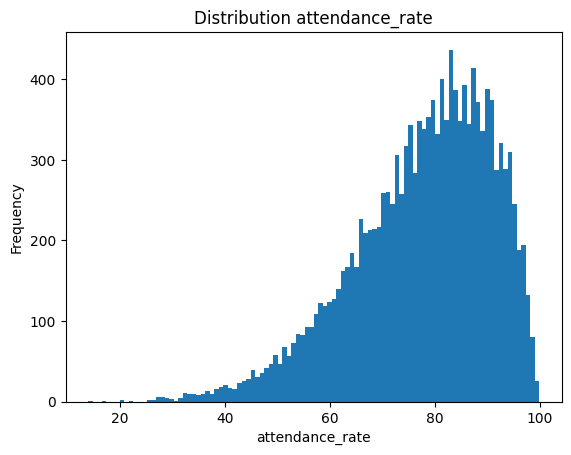

In [107]:
plt.hist(df['attendance_rate'], bins=100)
plt.xlabel('attendance_rate')
plt.ylabel('Frequency')
plt.title('Distribution attendance_rate')
plt.show()

In [108]:
df[cols_with_missing_values].skew()

sat_score          0.018972
current_gpa       -0.271797
attendance_rate   -0.787862
dtype: float64

### fill missing values

In [109]:
fill_mean_cols = ['sat_score', 'current_gpa']

util.fill_with_mean(df, fill_mean_cols)

# fill attendance_rate with median as it is highly skewed
util.fill_with_median(df, ['attendance_rate'])

In [110]:
df[cols_with_missing_values].isnull().sum()

sat_score          0
current_gpa        0
attendance_rate    0
dtype: int64

## changing datatype of yes/no columns to bool(0, 1)

In [111]:
df.nunique()[df.nunique() == 2]

first_generation_college             2
international_student                2
enrollment_status                    2
financial_aid_received               2
pell_grant_eligible (scholarship)    2
has_campus_job                       2
has_disability                       2
dropped_out                          2
dtype: int64

In [112]:
df.head()

,student_id,age,gender,first_generation_college,international_student,residency_status,high_school_gpa,sat_score,act_score,advanced_courses_taken,extracurricular_activities,major,enrollment_status,semester_credits,admission_type,starting_semester,family_income,financial_aid_received,pell_grant_eligible (scholarship),student_loan_amount,has_campus_job,current_gpa,credits_completed,courses_failed,courses_withdrawn,attendance_rate,study_hours_per_week,library_visits_per_month,tutoring_sessions_attended,advisor_meetings,clubs_joined,living_arrangement,has_disability,distance_from_campus_miles,work_hours_per_week,dropped_out
0,STU_00000001,23,Male,No,No,In-state,2.88,1034.0,26,2,2,Health Sciences,Full-time,12,Transfer,Fall,$30k-$60k,Yes,No,239,Yes,3.63,23,0,0,73.6,21,0,0,3,0,On-campus,No,64,18,No
1,STU_00000002,20,Male,Yes,No,In-state,2.79,1162.0,20,3,2,Social Sciences,Full-time,18,Regular,Spring,$60k-$100k,No,Yes,24364,No,1.92,45,2,3,77.6,11,4,2,1,2,On-campus,No,0,2,Yes
2,STU_00000003,19,Female,No,No,In-state,3.44,1264.0,22,5,2,Arts & Sciences,Full-time,12,Regular,Fall,$60k-$100k,Yes,No,18313,Yes,2.13,96,0,0,69.9,28,2,2,1,0,On-campus,No,10,5,Yes
3,STU_00000004,17,Male,No,Yes,In-state,2.86,966.0,28,4,3,Engineering,Full-time,18,Regular,Fall,$30k-$60k,Yes,No,11918,Yes,3.22,3,0,1,83.8,24,1,0,0,1,Off-campus,No,24,27,No
4,STU_00000005,17,Male,Yes,Yes,Out-of-state,3.77,1174.0,25,8,1,Business,Full-time,15,Early Decision,Fall,$30k-$60k,Yes,No,6449,No,3.18,1,1,1,79.8,7,7,5,1,0,On-campus,No,15,10,No


In [113]:
df.rename(columns={'pell_grant_eligible (scholarship)': 'pell_grant_eligible'}, inplace=True)

In [114]:
cols_to_bool = ['first_generation_college', 'international_student', 'financial_aid_received', 'pell_grant_eligible',
                 'has_campus_job', 'has_disability', 'dropped_out']

In [115]:
df[cols_to_bool] = df[cols_to_bool].apply(lambda col: col.str.lower().map({'yes': True, 'no': False}))

In [116]:
df.head()

,student_id,age,gender,first_generation_college,international_student,residency_status,high_school_gpa,sat_score,act_score,advanced_courses_taken,extracurricular_activities,major,enrollment_status,semester_credits,admission_type,starting_semester,family_income,financial_aid_received,pell_grant_eligible,student_loan_amount,has_campus_job,current_gpa,credits_completed,courses_failed,courses_withdrawn,attendance_rate,study_hours_per_week,library_visits_per_month,tutoring_sessions_attended,advisor_meetings,clubs_joined,living_arrangement,has_disability,distance_from_campus_miles,work_hours_per_week,dropped_out
0,STU_00000001,23,Male,False,False,In-state,2.88,1034.0,26,2,2,Health Sciences,Full-time,12,Transfer,Fall,$30k-$60k,True,False,239,True,3.63,23,0,0,73.6,21,0,0,3,0,On-campus,False,64,18,False
1,STU_00000002,20,Male,True,False,In-state,2.79,1162.0,20,3,2,Social Sciences,Full-time,18,Regular,Spring,$60k-$100k,False,True,24364,False,1.92,45,2,3,77.6,11,4,2,1,2,On-campus,False,0,2,True
2,STU_00000003,19,Female,False,False,In-state,3.44,1264.0,22,5,2,Arts & Sciences,Full-time,12,Regular,Fall,$60k-$100k,True,False,18313,True,2.13,96,0,0,69.9,28,2,2,1,0,On-campus,False,10,5,True
3,STU_00000004,17,Male,False,True,In-state,2.86,966.0,28,4,3,Engineering,Full-time,18,Regular,Fall,$30k-$60k,True,False,11918,True,3.22,3,0,1,83.8,24,1,0,0,1,Off-campus,False,24,27,False
4,STU_00000005,17,Male,True,True,Out-of-state,3.77,1174.0,25,8,1,Business,Full-time,15,Early Decision,Fall,$30k-$60k,True,False,6449,False,3.18,1,1,1,79.8,7,7,5,1,0,On-campus,False,15,10,False


In [117]:
df[cols_to_bool].dtypes

first_generation_college    bool
international_student       bool
financial_aid_received      bool
pell_grant_eligible         bool
has_campus_job              bool
has_disability              bool
dropped_out                 bool
dtype: object

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  15000 non-null  object 
 1   age                         15000 non-null  int64  
 2   gender                      15000 non-null  object 
 3   first_generation_college    15000 non-null  bool   
 4   international_student       15000 non-null  bool   
 5   residency_status            15000 non-null  object 
 6   high_school_gpa             15000 non-null  float64
 7   sat_score                   15000 non-null  float64
 8   act_score                   15000 non-null  int64  
 9   advanced_courses_taken      15000 non-null  int64  
 10  extracurricular_activities  15000 non-null  int64  
 11  major                       15000 non-null  object 
 12  enrollment_status           15000 non-null  object 
 13  semester_credits            150

### check for duplicates

In [119]:
df.duplicated().sum()

np.int64(0)

### remove stu_ prefix from student_id

In [120]:
df['student_id'] = df['student_id'].str.replace('STU_', '').astype(int)

In [121]:
df.head()

,student_id,age,gender,first_generation_college,international_student,residency_status,high_school_gpa,sat_score,act_score,advanced_courses_taken,extracurricular_activities,major,enrollment_status,semester_credits,admission_type,starting_semester,family_income,financial_aid_received,pell_grant_eligible,student_loan_amount,has_campus_job,current_gpa,credits_completed,courses_failed,courses_withdrawn,attendance_rate,study_hours_per_week,library_visits_per_month,tutoring_sessions_attended,advisor_meetings,clubs_joined,living_arrangement,has_disability,distance_from_campus_miles,work_hours_per_week,dropped_out
0,1,23,Male,False,False,In-state,2.88,1034.0,26,2,2,Health Sciences,Full-time,12,Transfer,Fall,$30k-$60k,True,False,239,True,3.63,23,0,0,73.6,21,0,0,3,0,On-campus,False,64,18,False
1,2,20,Male,True,False,In-state,2.79,1162.0,20,3,2,Social Sciences,Full-time,18,Regular,Spring,$60k-$100k,False,True,24364,False,1.92,45,2,3,77.6,11,4,2,1,2,On-campus,False,0,2,True
2,3,19,Female,False,False,In-state,3.44,1264.0,22,5,2,Arts & Sciences,Full-time,12,Regular,Fall,$60k-$100k,True,False,18313,True,2.13,96,0,0,69.9,28,2,2,1,0,On-campus,False,10,5,True
3,4,17,Male,False,True,In-state,2.86,966.0,28,4,3,Engineering,Full-time,18,Regular,Fall,$30k-$60k,True,False,11918,True,3.22,3,0,1,83.8,24,1,0,0,1,Off-campus,False,24,27,False
4,5,17,Male,True,True,Out-of-state,3.77,1174.0,25,8,1,Business,Full-time,15,Early Decision,Fall,$30k-$60k,True,False,6449,False,3.18,1,1,1,79.8,7,7,5,1,0,On-campus,False,15,10,False


In [122]:
df['family_income'].nunique()

4

In [123]:
df['family_income'].unique()

array(['$30k-$60k', '$60k-$100k', '<$30k', '$100k+'], dtype=object)

In [124]:
df.head()

,student_id,age,gender,first_generation_college,international_student,residency_status,high_school_gpa,sat_score,act_score,advanced_courses_taken,extracurricular_activities,major,enrollment_status,semester_credits,admission_type,starting_semester,family_income,financial_aid_received,pell_grant_eligible,student_loan_amount,has_campus_job,current_gpa,credits_completed,courses_failed,courses_withdrawn,attendance_rate,study_hours_per_week,library_visits_per_month,tutoring_sessions_attended,advisor_meetings,clubs_joined,living_arrangement,has_disability,distance_from_campus_miles,work_hours_per_week,dropped_out
0,1,23,Male,False,False,In-state,2.88,1034.0,26,2,2,Health Sciences,Full-time,12,Transfer,Fall,$30k-$60k,True,False,239,True,3.63,23,0,0,73.6,21,0,0,3,0,On-campus,False,64,18,False
1,2,20,Male,True,False,In-state,2.79,1162.0,20,3,2,Social Sciences,Full-time,18,Regular,Spring,$60k-$100k,False,True,24364,False,1.92,45,2,3,77.6,11,4,2,1,2,On-campus,False,0,2,True
2,3,19,Female,False,False,In-state,3.44,1264.0,22,5,2,Arts & Sciences,Full-time,12,Regular,Fall,$60k-$100k,True,False,18313,True,2.13,96,0,0,69.9,28,2,2,1,0,On-campus,False,10,5,True
3,4,17,Male,False,True,In-state,2.86,966.0,28,4,3,Engineering,Full-time,18,Regular,Fall,$30k-$60k,True,False,11918,True,3.22,3,0,1,83.8,24,1,0,0,1,Off-campus,False,24,27,False
4,5,17,Male,True,True,Out-of-state,3.77,1174.0,25,8,1,Business,Full-time,15,Early Decision,Fall,$30k-$60k,True,False,6449,False,3.18,1,1,1,79.8,7,7,5,1,0,On-campus,False,15,10,False


## save as csv

In [125]:
df.to_csv('../data/interim/cleaned_data.csv', index=False)